# Decision Tree & Random Forest — No-Framework Implementation

Building both Decision Tree and Random Forest from scratch using only NumPy. Most algorithmically complex from-scratch build in the project — involves a recursive data structure (the tree itself).

**Part 1: Decision Tree** (baseline — demonstrates overfitting)
- Recursive tree building with Gini impurity split criterion
- Weighted impurity for class imbalance (88.7/11.3 ratio)
- Depth analysis sweep to find optimal `max_depth`

**Part 2: Random Forest** (main event — fixes overfitting via bagging)
- Bootstrap sampling + random feature subsets (`sqrt(n_features)`)
- Majority vote across 100 trees, averaged probabilities
- Manual OOB score computation (our showcase)

**Showcase**: Gini vs Entropy comparison (Part 1) + Manual OOB score (Part 2) — demonstrating core math behind split criteria and out-of-bag validation.

## What We Build From Scratch
- **Gini impurity**: `1 - sum(p_k^2)` — probability of misclassification
- **Entropy**: `-sum(p_k * log(p_k))` — information content
- **Information gain**: parent impurity minus weighted child impurity
- **Recursive tree building**: greedy best-split search at each node
- **Bootstrap aggregating (bagging)**: sampling with replacement + ensemble vote
- **OOB score**: validation using out-of-bag samples per tree

In [1]:
# Step 1: Imports, config, and data loading
import numpy as np
import sys
import os

# Add project root to path for shared utilities
sys.path.insert(0, os.path.abspath('../..'))

from utils.data_loader import load_processed_data
from utils.metrics import evaluate_classifier, print_metrics
from utils.performance import track_performance, track_inference, get_model_size
from utils.visualization import (plot_confusion_matrix, plot_roc_curve,
                                  plot_feature_importance, plot_calibration_curve,
                                  plot_tree_depth_analysis, plot_forest_convergence)
from utils.results import save_results, add_result, print_comparison, build_results_dict
from utils.tree_utils import compute_feature_importance, flatten_tree, predict_batch

# Configuration
RANDOM_STATE = 113
FRAMEWORK = 'No-Framework'
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# DT depth sweep values (same as sklearn for fair comparison)
DEPTH_VALUES = [2, 3, 5, 7, 10, 15, 20, None]

# RF configuration
N_ESTIMATORS = 100
MAX_FEATURES = 'sqrt'  # sqrt(19) ≈ 4 random features per split

# Set random seed for reproducibility
np.random.seed(RANDOM_STATE)

# Load preprocessed data
X_train, X_test, y_train, y_test, metadata = load_processed_data('decision_tree')
feature_names = metadata['feature_names']
n_features = metadata['n_features']

print("=" * 60)
print(f"DECISION TREE & RANDOM FOREST — {FRAMEWORK}")
print("=" * 60)
print(f"\nDataset: {metadata['dataset']}")
print(f"Features: {n_features} ({len(metadata['categorical_features'])} categorical, "
      f"{len(metadata['continuous_features'])} continuous)")
print(f"Training: {X_train.shape[0]:,} samples")
print(f"Test:     {X_test.shape[0]:,} samples")
print(f"Classes:  {metadata['class_names']}")
print(f"Train class dist: 0={np.sum(y_train==0):,}, 1={np.sum(y_train==1):,} "
      f"({np.mean(y_train==1)*100:.1f}% positive)")
print(f"\nDropped: {list(metadata['dropped_features'].keys())} (data leakage)")
print(f"Scaling: {metadata['scaling']}")

DECISION TREE & RANDOM FOREST — No-Framework

Dataset: Bank Marketing (UCI)
Features: 19 (10 categorical, 9 continuous)
Training: 32,950 samples
Test:     8,238 samples
Classes:  ['no', 'yes']
Train class dist: 0=29,238, 1=3,712 (11.3% positive)

Dropped: ['duration'] (data leakage)
Scaling: None (trees are scale-invariant)


In [2]:
# Step 2: Split criterion functions
def compute_sample_weights(y):
    """
    Compute balanced class weights (matches sklearn's class_weight='balanced').

    Each sample gets weight = n_samples / (n_classes * n_samples_in_class).
    This makes the minority class (11.3% positive) contribute equally to
    impurity as the majority class, preventing the tree from always
    predicting 'no'.

    Args:
        y: Labels array (n_samples,)

    Returns:
        weights: Per-sample weight array (n_samples,)
    """
    classes = np.unique(y)
    n_samples = len(y)
    n_classes = len(classes)

    weights = np.zeros(n_samples)
    for cls in classes:
        mask = y == cls
        n_cls = mask.sum()
        weights[mask] = n_samples / (n_classes * n_cls)

    return weights


def gini_impurity(y, sample_weight=None):
    """
    Gini impurity: probability of misclassifying a randomly chosen sample.

    Gini = 1 - sum(p_k^2), where p_k is the (weighted) proportion of class k.
    - Gini = 0.0: pure node (all samples same class)
    - Gini = 0.5: maximum impurity for binary (50/50 split)

    Args:
        y: Labels at this node (n_samples,)
        sample_weight: Per-sample weights (n_samples,). None = uniform.

    Returns:
        float: Gini impurity in [0, 0.5] for binary classification
    """
    if len(y) == 0:
        return 0.0

    classes = np.unique(y)

    if sample_weight is None:
        proportions = np.array([np.mean(y == c) for c in classes])
    else:
        total_weight = sample_weight.sum()
        if total_weight == 0:
            return 0.0
        proportions = np.array([
            sample_weight[y == c].sum() / total_weight for c in classes
        ])

    return 1.0 - np.sum(proportions ** 2)


def entropy_impurity(y, sample_weight=None):
    """
    Shannon entropy: information content of the class distribution.

    Entropy = -sum(p_k * log2(p_k)), where p_k is the (weighted) proportion.
    - Entropy = 0.0: pure node (all same class)
    - Entropy = 1.0: maximum for binary (50/50 split)

    Args:
        y: Labels at this node (n_samples,)
        sample_weight: Per-sample weights (n_samples,). None = uniform.

    Returns:
        float: Entropy >= 0
    """
    if len(y) == 0:
        return 0.0

    classes = np.unique(y)

    if sample_weight is None:
        proportions = np.array([np.mean(y == c) for c in classes])
    else:
        total_weight = sample_weight.sum()
        if total_weight == 0:
            return 0.0
        proportions = np.array([
            sample_weight[y == c].sum() / total_weight for c in classes
        ])

    # Filter out zeros to avoid log2(0)
    proportions = proportions[proportions > 0]
    return -np.sum(proportions * np.log2(proportions))


def information_gain(y_parent, y_left, y_right, criterion='gini',
                     sw_parent=None, sw_left=None, sw_right=None):
    """
    Information gain from splitting parent into left and right children.

    IG = impurity(parent) - weighted_average(impurity(children))
    Higher IG = split separates classes more effectively.

    Args:
        y_parent, y_left, y_right: Labels for parent and children
        criterion: 'gini' or 'entropy'
        sw_parent, sw_left, sw_right: Sample weights (None = uniform)

    Returns:
        float: Information gain >= 0
    """
    imp_func = gini_impurity if criterion == 'gini' else entropy_impurity

    parent_imp = imp_func(y_parent, sw_parent)

    # Weight children by their (weighted) sample count
    if sw_parent is None:
        n = len(y_parent)
        w_left = len(y_left) / n
        w_right = len(y_right) / n
    else:
        total = sw_parent.sum()
        w_left = sw_left.sum() / total
        w_right = sw_right.sum() / total

    child_imp = (w_left * imp_func(y_left, sw_left) +
                 w_right * imp_func(y_right, sw_right))

    return parent_imp - child_imp

In [3]:
# Test all functions
sample_weights = compute_sample_weights(y_train)

print("=" * 60)
print("[1/4] SAMPLE WEIGHTS (Balanced Class Weighting)")
print("=" * 60)
print(f"  Class 0 (no):  weight = {sample_weights[y_train == 0][0]:.4f} "
      f"({np.sum(y_train == 0):,} samples)")
print(f"  Class 1 (yes): weight = {sample_weights[y_train == 1][0]:.4f} "
      f"({np.sum(y_train == 1):,} samples)")
print(f"  Effective ratio: 1:{sample_weights[y_train == 1][0] / sample_weights[y_train == 0][0]:.1f} "
      f"(minority upweighted)")

print(f"\n{'=' * 60}")
print("[2/4] GINI IMPURITY")
print("=" * 60)
pure = np.array([0, 0, 0, 0, 0])
balanced = np.array([0, 0, 1, 1])
print(f"  Pure node [0,0,0,0,0]:       Gini = {gini_impurity(pure):.4f}")
print(f"  Balanced [0,0,1,1]:          Gini = {gini_impurity(balanced):.4f}")
print(f"  Training data (unweighted):  Gini = {gini_impurity(y_train):.4f}")
print(f"  Training data (weighted):    Gini = {gini_impurity(y_train, sample_weights):.4f}")

print(f"\n{'=' * 60}")
print("[3/4] ENTROPY")
print("=" * 60)
print(f"  Pure node [0,0,0,0,0]:       Entropy = {entropy_impurity(pure):.4f}")
print(f"  Balanced [0,0,1,1]:          Entropy = {entropy_impurity(balanced):.4f}")
print(f"  Training data (unweighted):  Entropy = {entropy_impurity(y_train):.4f}")
print(f"  Training data (weighted):    Entropy = {entropy_impurity(y_train, sample_weights):.4f}")

print(f"\n{'=' * 60}")
print("[4/4] INFORMATION GAIN (Sample Split)")
print("=" * 60)
feat_idx = 0
threshold = np.median(X_train[:, feat_idx])
left_mask = X_train[:, feat_idx] <= threshold
right_mask = ~left_mask

ig_gini = information_gain(
    y_train, y_train[left_mask], y_train[right_mask], criterion='gini',
    sw_parent=sample_weights, sw_left=sample_weights[left_mask],
    sw_right=sample_weights[right_mask]
)
ig_entropy = information_gain(
    y_train, y_train[left_mask], y_train[right_mask], criterion='entropy',
    sw_parent=sample_weights, sw_left=sample_weights[left_mask],
    sw_right=sample_weights[right_mask]
)
print(f"  Split: {feature_names[feat_idx]} <= {threshold:.2f}")
print(f"  Left: {left_mask.sum():,} samples, Right: {right_mask.sum():,} samples")
print(f"  IG (Gini):    {ig_gini:.6f}")
print(f"  IG (Entropy): {ig_entropy:.6f}")

[1/4] SAMPLE WEIGHTS (Balanced Class Weighting)
  Class 0 (no):  weight = 0.5635 (29,238 samples)
  Class 1 (yes): weight = 4.4383 (3,712 samples)
  Effective ratio: 1:7.9 (minority upweighted)

[2/4] GINI IMPURITY
  Pure node [0,0,0,0,0]:       Gini = 0.0000
  Balanced [0,0,1,1]:          Gini = 0.5000
  Training data (unweighted):  Gini = 0.1999
  Training data (weighted):    Gini = 0.5000

[3/4] ENTROPY
  Pure node [0,0,0,0,0]:       Entropy = -0.0000
  Balanced [0,0,1,1]:          Entropy = 1.0000
  Training data (unweighted):  Entropy = 0.5079
  Training data (weighted):    Entropy = 1.0000

[4/4] INFORMATION GAIN (Sample Split)
  Split: age <= 38.00
  Left: 16,972 samples, Right: 15,978 samples
  IG (Gini):    0.000510
  IG (Entropy): 0.000736


In [4]:
# Step 3: Tree building — find_best_split + build_tree
def find_best_split(X, y, sample_weight, feature_indices=None, criterion='gini'):
    """
    Find the optimal feature and threshold to split a node.

    Uses sorted scan (same core algorithm as sklearn's Cython implementation):
    for each candidate feature, sort samples by value, then scan left-to-right
    maintaining running weighted class counts. Each threshold evaluation is O(1)
    instead of O(n), making total cost O(n_features * n * log(n)) per node.

    Args:
        X: Features at this node (n_samples, n_features)
        y: Labels at this node (n_samples,)
        sample_weight: Per-sample weights (n_samples,)
        feature_indices: Which features to consider (None = all).
                        Random Forest passes a random sqrt(n) subset here.
        criterion: 'gini' or 'entropy'

    Returns:
        dict with 'feature', 'threshold', 'gain', or None if no valid split
    """
    n_samples = X.shape[0]

    if feature_indices is None:
        feature_indices = range(X.shape[1])

    # Parent impurity — same for all candidate splits, compute once
    imp_func = gini_impurity if criterion == 'gini' else entropy_impurity
    parent_imp = imp_func(y, sample_weight)

    best_gain = 0.0
    best_split = None

    for feat in feature_indices:
        # Sort samples by this feature's values
        sorted_idx = np.argsort(X[:, feat])
        sorted_y = y[sorted_idx]
        sorted_w = sample_weight[sorted_idx]
        sorted_vals = X[sorted_idx, feat]

        # Initialize running counts: all samples start in the right child
        n_classes = 2
        left_w = np.zeros(n_classes)
        right_w = np.zeros(n_classes)
        for c in range(n_classes):
            right_w[c] = sorted_w[sorted_y == c].sum()
        total_w = sorted_w.sum()

        # Scan left to right: move one sample at a time from right to left
        for i in range(n_samples - 1):
            c = int(sorted_y[i])
            left_w[c] += sorted_w[i]
            right_w[c] -= sorted_w[i]

            # Only evaluate at boundaries between different values
            # (splitting between identical values produces the same result)
            if sorted_vals[i] == sorted_vals[i + 1]:
                continue

            # Compute child impurities from running weight counts
            left_total = left_w.sum()
            right_total = right_w.sum()

            if criterion == 'gini':
                left_p = left_w / left_total
                right_p = right_w / right_total
                left_imp = 1.0 - np.sum(left_p ** 2)
                right_imp = 1.0 - np.sum(right_p ** 2)
            else:
                left_p = left_w / left_total
                right_p = right_w / right_total
                lp_nz = left_p[left_p > 0]
                rp_nz = right_p[right_p > 0]
                left_imp = -np.sum(lp_nz * np.log2(lp_nz))
                right_imp = -np.sum(rp_nz * np.log2(rp_nz))

            # Weighted child impurity
            child_imp = (left_total / total_w * left_imp +
                         right_total / total_w * right_imp)
            gain = parent_imp - child_imp

            if gain > best_gain:
                best_gain = gain
                best_split = {
                    'feature': feat,
                    'threshold': (sorted_vals[i] + sorted_vals[i + 1]) / 2,
                    'gain': gain
                }

    return best_split


def build_tree(X, y, sample_weight, max_depth=None, min_samples_split=2,
               feature_indices=None, criterion='gini', depth=0):
    """
    Recursively build a decision tree using greedy best-split search.

    Returns a dict-based tree compatible with tree_utils.py functions:
    - Leaf: {'value': [w0, w1], 'n_samples': n, 'impurity': imp}
    - Split: {'feature': f, 'threshold': t, 'left': {...}, 'right': {...},
              'n_samples': n, 'impurity': imp}

    Args:
        X: Features (n_samples, n_features)
        y: Labels (n_samples,)
        sample_weight: Per-sample weights (n_samples,)
        max_depth: Maximum tree depth (None = grow until pure)
        min_samples_split: Minimum samples required to attempt a split
        feature_indices: Features to consider (None = all, for RF: random subset)
        criterion: 'gini' or 'entropy'
        depth: Current depth (internal, starts at 0)

    Returns:
        dict: Tree node (recursive structure)
    """
    n_samples = len(y)
    n_classes = 2

    # Class distribution — weighted counts per class
    value = np.zeros(n_classes)
    for c in np.unique(y):
        value[int(c)] = sample_weight[y == c].sum()

    # Node impurity
    imp_func = gini_impurity if criterion == 'gini' else entropy_impurity
    impurity = imp_func(y, sample_weight)

    # Stopping conditions
    if (len(np.unique(y)) == 1 or                              # Pure node
        (max_depth is not None and depth >= max_depth) or       # Max depth reached
        n_samples < min_samples_split):                         # Too few samples
        return {'value': value, 'n_samples': n_samples, 'impurity': impurity}

    # Find best split across candidate features
    split = find_best_split(X, y, sample_weight, feature_indices, criterion)

    if split is None:
        # No valid split (e.g., all features identical at this node)
        return {'value': value, 'n_samples': n_samples, 'impurity': impurity}

    # Partition data
    left_mask = X[:, split['feature']] <= split['threshold']
    right_mask = ~left_mask

    # Recurse into children
    left_child = build_tree(
        X[left_mask], y[left_mask], sample_weight[left_mask],
        max_depth, min_samples_split, feature_indices, criterion, depth + 1
    )
    right_child = build_tree(
        X[right_mask], y[right_mask], sample_weight[right_mask],
        max_depth, min_samples_split, feature_indices, criterion, depth + 1
    )

    return {
        'feature': split['feature'],
        'threshold': split['threshold'],
        'left': left_child,
        'right': right_child,
        'value': value,
        'n_samples': n_samples,
        'impurity': impurity
    }

def get_tree_depth(node):
    """Get the maximum depth of a tree."""
    if 'feature' not in node:
        return 0
    return 1 + max(get_tree_depth(node['left']), get_tree_depth(node['right']))


def get_n_leaves(node):
    """Count the number of leaf nodes."""
    if 'feature' not in node:
        return 1
    return get_n_leaves(node['left']) + get_n_leaves(node['right'])

In [5]:
# Quick test: build a small tree (max_depth=3)
print("=" * 60)
print("TREE BUILDING — Quick Test (max_depth=3)")
print("=" * 60)

test_tree = build_tree(X_train, y_train, sample_weights, max_depth=3, criterion='gini')

print(f"  Tree depth: {get_tree_depth(test_tree)}")
print(f"  Leaves:     {get_n_leaves(test_tree)}")
print(f"  Root split: {feature_names[test_tree['feature']]} <= {test_tree['threshold']:.4f}")
print(f"  Root impurity: {test_tree['impurity']:.4f}")
print(f"  Root samples:  {test_tree['n_samples']:,}")

# Verify prediction pipeline: build_tree → flatten_tree → predict_batch
flat = flatten_tree(test_tree)
test_preds, test_proba = predict_batch(flat, X_test[:5])
print(f"\n  Predictions (first 5): {test_preds}")
print(f"  Actual (first 5):      {y_test[:5].astype(int)}")
print(f"  Proba sums to 1: {np.allclose(test_proba.sum(axis=1), 1.0)}")

TREE BUILDING — Quick Test (max_depth=3)
  Tree depth: 3
  Leaves:     8
  Root split: nr.employed <= 5087.6500
  Root impurity: 0.5000
  Root samples:  32,950

  Predictions (first 5): [0 0 0 0 0]
  Actual (first 5):      [0 0 0 0 0]
  Proba sums to 1: True


In [6]:
# PART 1 / Step 4: DECISION TREE (No Depth Limit — Demonstrates Overfitting)
print("=" * 60)
print("PART 1: DECISION TREE (No Depth Limit)")
print("=" * 60)
print("Building unrestricted tree (pure Python — slower than sklearn's Cython)...\n")

with track_performance() as dt_perf:
    dt_tree = build_tree(X_train, y_train, sample_weights,
                         max_depth=None, criterion='gini')

# Predictions via flatten_tree → predict_batch pipeline
dt_flat = flatten_tree(dt_tree)
dt_train_pred, dt_train_proba = predict_batch(dt_flat, X_train)
dt_test_pred, dt_test_proba = predict_batch(dt_flat, X_test)

# Evaluate both sets (binary: pass P(class=1) for probabilistic metrics)
dt_train_metrics = evaluate_classifier(y_train, dt_train_pred, dt_train_proba[:, 1])
dt_test_metrics = evaluate_classifier(y_test, dt_test_pred, dt_test_proba[:, 1])

print(f"Training time: {dt_perf['time']:.2f}s (sklearn: ~0.10s)")
print(f"Tree depth: {get_tree_depth(dt_tree)}")
print(f"Number of leaves: {get_n_leaves(dt_tree)}")

print_metrics(dt_train_metrics, dt_test_metrics, title="Decision Tree (Unrestricted)")

print("\n! Notice the gap between train and test metrics — this is OVERFITTING.")
print("The unrestricted tree memorizes the training data perfectly.")

PART 1: DECISION TREE (No Depth Limit)
Building unrestricted tree (pure Python — slower than sklearn's Cython)...

Training time: 92.84s (sklearn: ~0.10s)
Tree depth: 42
Number of leaves: 5384

METRICS — Decision Tree (Unrestricted)
Metric                           Train         Test
-------------------------------------------------
accuracy                        0.9940       0.8415
precision                       0.9491       0.3064
recall                          1.0000       0.3222
f1                              0.9739       0.3141
auc                             0.9999       0.6025
log_loss                        0.0128       5.2355
brier_score                     0.0045       0.1568
ece                             0.0045       0.0811

! Notice the gap between train and test metrics — this is OVERFITTING.
The unrestricted tree memorizes the training data perfectly.


DEPTH ANALYSIS — Finding Optimal max_depth
(Pure Python — each depth takes 5-90s)

  max_depth=2             train=0.8353  test=0.8344  gap=0.0009
  max_depth=3             train=0.8354  test=0.8345  gap=0.0009
  max_depth=5             train=0.8154  test=0.8106  gap=0.0047
  max_depth=7             train=0.8217  test=0.8126  gap=0.0091
  max_depth=10            train=0.8399  test=0.8172  gap=0.0227
  max_depth=15            train=0.8795  test=0.8188  gap=0.0607
  max_depth=20            train=0.9223  test=0.8208  gap=0.1015
  max_depth=None (full)   train=0.9940  test=0.8415  gap=0.1525


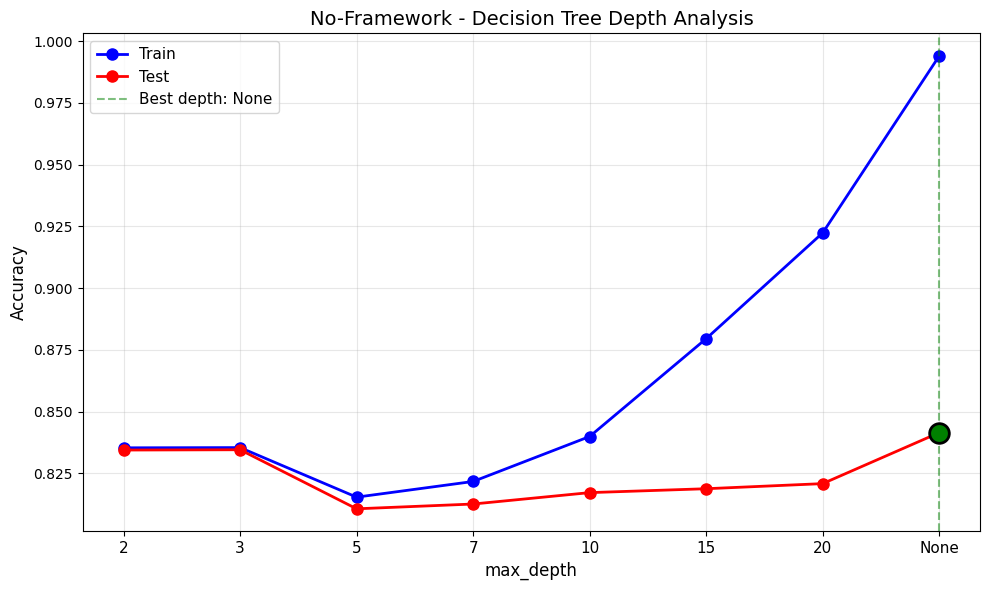


Optimal max_depth: None (test accuracy: 0.8415)

Retraining with max_depth=None...

Tree depth: 42, Leaves: 5384

METRICS — Decision Tree (max_depth=None)
Metric                           Train         Test
-------------------------------------------------
accuracy                        0.9940       0.8415
precision                       0.9491       0.3064
recall                          1.0000       0.3222
f1                              0.9739       0.3141
auc                             0.9999       0.6025
log_loss                        0.0128       5.2355
brier_score                     0.0045       0.1568
ece                             0.0045       0.0811


In [7]:
# Step 5: Depth analysis — find optimal max_depth
print("=" * 60)
print("DEPTH ANALYSIS — Finding Optimal max_depth")
print("=" * 60)
print("(Pure Python — each depth takes 5-90s)\n")

train_scores = []
test_scores = []

for depth in DEPTH_VALUES:
    if depth is None:
        # Reuse unrestricted tree from Cell 5 (already took 92s)
        train_acc = dt_train_metrics['accuracy']
        test_acc = dt_test_metrics['accuracy']
    else:
        tree = build_tree(X_train, y_train, sample_weights,
                          max_depth=depth, criterion='gini')
        flat = flatten_tree(tree)
        train_pred, _ = predict_batch(flat, X_train)
        test_pred, _ = predict_batch(flat, X_test)
        train_acc = np.mean(train_pred == y_train)
        test_acc = np.mean(test_pred == y_test)

    train_scores.append(train_acc)
    test_scores.append(test_acc)

    depth_label = depth if depth is not None else "None (full)"
    print(f"  max_depth={str(depth_label):12s}  train={train_acc:.4f}  test={test_acc:.4f}  "
          f"gap={train_acc - test_acc:.4f}")

# Plot depth analysis
plot_tree_depth_analysis(DEPTH_VALUES, train_scores, test_scores, FRAMEWORK,
                         save_path=f'{RESULTS_DIR}/dt_depth_analysis.png')

# Find optimal depth
best_idx = np.argmax(test_scores)
best_depth = DEPTH_VALUES[best_idx]
print(f"\nOptimal max_depth: {best_depth} (test accuracy: {test_scores[best_idx]:.4f})")

# Retrain with optimal depth
print(f"\nRetraining with max_depth={best_depth}...")
with track_performance() as dt_perf:
    dt_tree = build_tree(X_train, y_train, sample_weights,
                         max_depth=best_depth, criterion='gini')

dt_flat = flatten_tree(dt_tree)
dt_train_pred, dt_train_proba = predict_batch(dt_flat, X_train)
dt_test_pred, dt_test_proba = predict_batch(dt_flat, X_test)

dt_train_metrics = evaluate_classifier(y_train, dt_train_pred, dt_train_proba[:, 1])
dt_test_metrics = evaluate_classifier(y_test, dt_test_pred, dt_test_proba[:, 1])

print(f"\nTree depth: {get_tree_depth(dt_tree)}, Leaves: {get_n_leaves(dt_tree)}")
print_metrics(dt_train_metrics, dt_test_metrics,
              title=f"Decision Tree (max_depth={best_depth})")

DECISION TREE VISUALIZATIONS


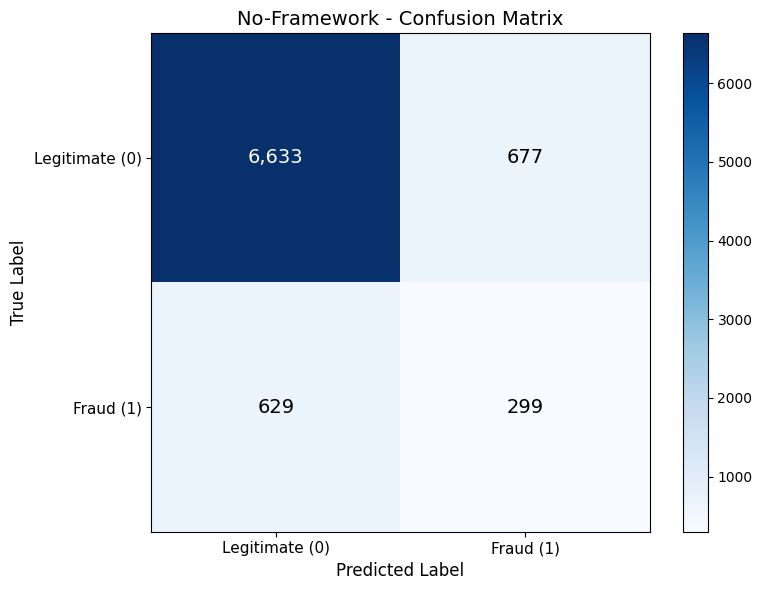

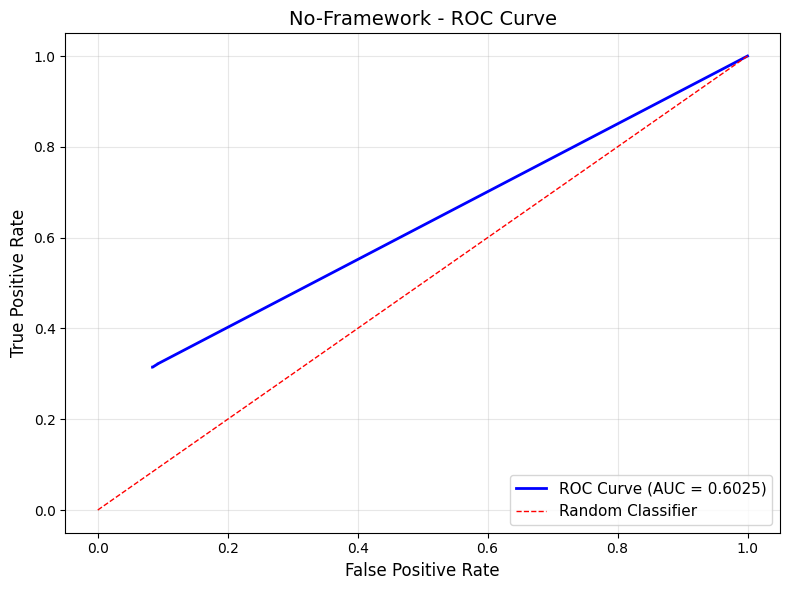

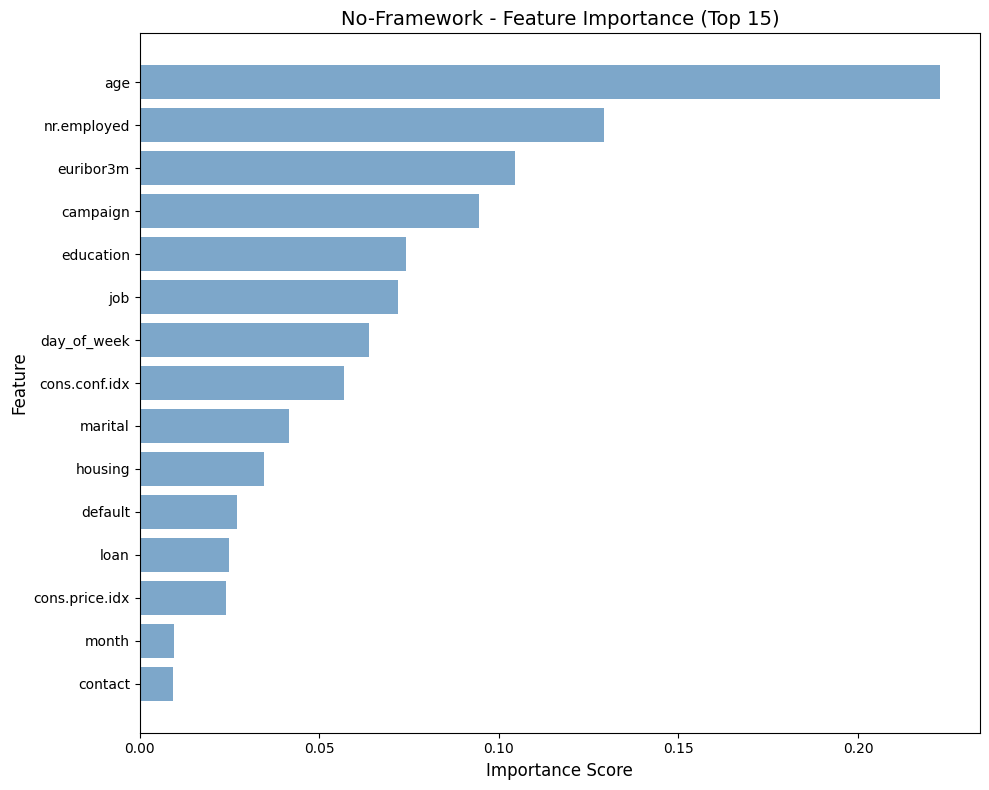

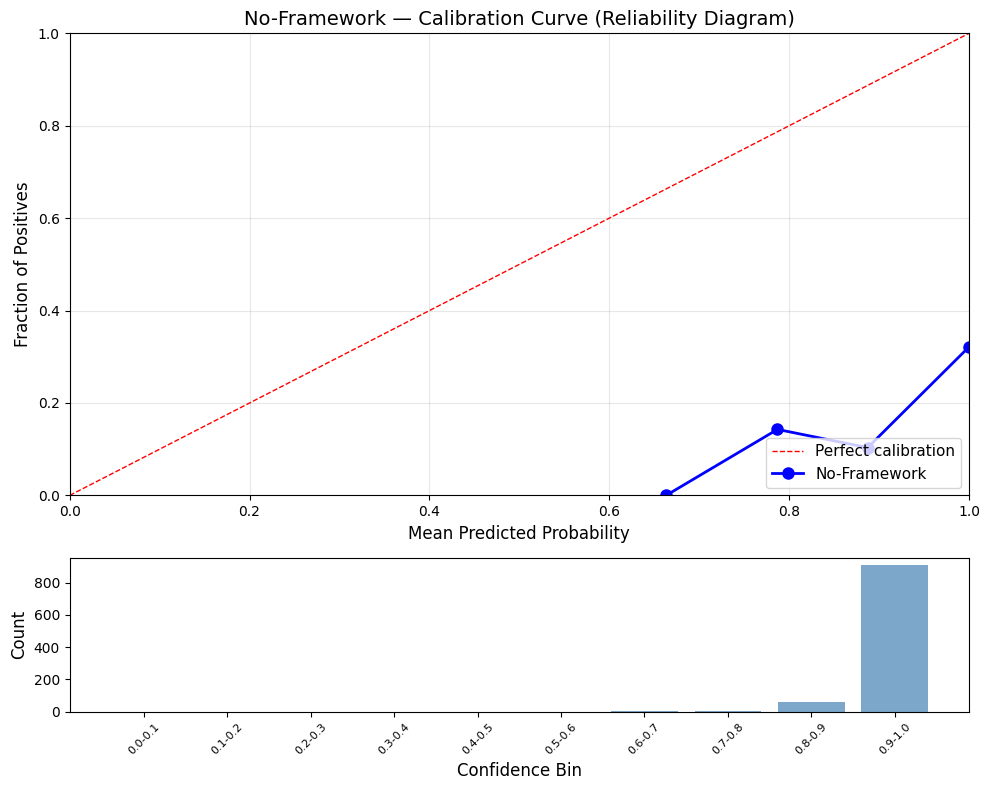


Top 5 features by Gini importance:
  1. age                 : 0.2228
  2. nr.employed         : 0.1291
  3. euribor3m           : 0.1044
  4. campaign            : 0.0944
  5. education           : 0.0742


In [8]:
# Step 6: Decision Tree visualizations
print("=" * 60)
print("DECISION TREE VISUALIZATIONS")
print("=" * 60)

# Confusion matrix
plot_confusion_matrix(y_test, dt_test_pred, FRAMEWORK,
                      save_path=f'{RESULTS_DIR}/dt_confusion_matrix.png')

# ROC curve
plot_roc_curve(y_test, dt_test_proba[:, 1], FRAMEWORK,
               save_path=f'{RESULTS_DIR}/dt_roc_curve.png')

# Feature importance via tree_utils (Gini importance from recursive tree)
dt_importances = compute_feature_importance(dt_tree, n_features)
plot_feature_importance(dt_importances, feature_names, FRAMEWORK,
                        save_path=f'{RESULTS_DIR}/dt_feature_importance.png',
                        mode='importance')

# Calibration curve
plot_calibration_curve(y_test, dt_test_proba[:, 1], FRAMEWORK,
                       save_path=f'{RESULTS_DIR}/dt_calibration.png')

# Print top 5 features
sorted_idx = np.argsort(dt_importances)[::-1]
print("\nTop 5 features by Gini importance:")
for i in range(5):
    idx = sorted_idx[i]
    print(f"  {i+1}. {feature_names[idx]:20s}: {dt_importances[idx]:.4f}")

In [9]:
# SHOWCASE PART 1: Gini vs Entropy Comparison
print("=" * 60)
print("SHOWCASE: Gini vs Entropy Split Criteria")
print("=" * 60)

"""
Both criteria measure impurity but with different math:
- Gini: 1 - sum(p_k^2) — probability of misclassification
- Entropy: -sum(p_k * log2(p_k)) — information content (bits)

Theory says they rarely produce different trees, but let's verify
with our from-scratch implementation on real data.
"""

# Build matched trees at depth 7 (enough depth to see differences)
print("\nBuilding Gini tree (max_depth=7)...")
gini_tree = build_tree(X_train, y_train, sample_weights,
                        max_depth=7, criterion='gini')
print("Building Entropy tree (max_depth=7)...")
entropy_tree = build_tree(X_train, y_train, sample_weights,
                           max_depth=7, criterion='entropy')

# Predict with both
gini_flat = flatten_tree(gini_tree)
entropy_flat = flatten_tree(entropy_tree)

gini_pred, gini_proba = predict_batch(gini_flat, X_test)
entropy_pred, entropy_proba = predict_batch(entropy_flat, X_test)

gini_metrics = evaluate_classifier(y_test, gini_pred, gini_proba[:, 1])
entropy_metrics = evaluate_classifier(y_test, entropy_pred, entropy_proba[:, 1])

# Compare
print(f"\n{'Metric':20s} {'Gini':>10s} {'Entropy':>10s} {'Difference':>12s}")
print("-" * 55)
for metric in ['accuracy', 'f1', 'auc', 'precision', 'recall']:
    g_val = gini_metrics[metric]
    e_val = entropy_metrics[metric]
    diff = e_val - g_val
    print(f"{metric:20s} {g_val:10.4f} {e_val:10.4f} {diff:+11.4f}")

# Compare tree structure
print(f"\n{'Structure':20s} {'Gini':>10s} {'Entropy':>10s}")
print("-" * 42)
print(f"{'Depth':20s} {get_tree_depth(gini_tree):10d} {get_tree_depth(entropy_tree):10d}")
print(f"{'Leaves':20s} {get_n_leaves(gini_tree):10d} {get_n_leaves(entropy_tree):10d}")

# Compare root splits
print(f"\nRoot split (Gini):    {feature_names[gini_tree['feature']]} <= {gini_tree['threshold']:.4f}")
print(f"Root split (Entropy): {feature_names[entropy_tree['feature']]} <= {entropy_tree['threshold']:.4f}")

# Feature importance comparison
gini_imp = compute_feature_importance(gini_tree, n_features)
entropy_imp = compute_feature_importance(entropy_tree, n_features)

print(f"\nTop 5 features — Gini vs Entropy:")
gini_top5 = np.argsort(gini_imp)[::-1][:5]
entropy_top5 = np.argsort(entropy_imp)[::-1][:5]
print(f"  Gini:    {[feature_names[i] for i in gini_top5]}")
print(f"  Entropy: {[feature_names[i] for i in entropy_top5]}")

# Prediction agreement
agreement = np.mean(gini_pred == entropy_pred)
print(f"\nPrediction agreement: {agreement:.1%}")
print(f"(Same prediction on {agreement:.1%} of test samples)")

SHOWCASE: Gini vs Entropy Split Criteria

Building Gini tree (max_depth=7)...
Building Entropy tree (max_depth=7)...

Metric                     Gini    Entropy   Difference
-------------------------------------------------------
accuracy                 0.8126     0.8144     +0.0018
f1                       0.4324     0.4360     +0.0036
auc                      0.7701     0.7710     +0.0009
precision                0.3281     0.3315     +0.0033
recall                   0.6336     0.6369     +0.0032

Structure                  Gini    Entropy
------------------------------------------
Depth                         7          7
Leaves                       94         99

Root split (Gini):    nr.employed <= 5087.6500
Root split (Entropy): nr.employed <= 5087.6500

Top 5 features — Gini vs Entropy:
  Gini:    ['nr.employed', 'cons.conf.idx', 'cons.price.idx', 'euribor3m', 'age']
  Entropy: ['nr.employed', 'cons.conf.idx', 'cons.price.idx', 'euribor3m', 'age']

Prediction agreement: 99.5%

## Part 2: Random Forest — Fixing Overfitting via Bagging

**How Random Forest improves on a single Decision Tree:**

1. **Bootstrap aggregating (bagging)** — each tree trains on a random sample (with replacement) of the training data, so no single tree sees everything
2. **Random feature subsets** — at each split, only `sqrt(n_features)` features are considered, forcing trees to learn different patterns
3. **Majority vote** — predictions are averaged across all trees, reducing variance (the main source of DT overfitting)

**What we build from scratch:**
- `bootstrap_sample()` — random sampling with replacement
- `build_forest()` — trains N independent trees, each on a bootstrap sample with random feature subsets
- `predict_forest()` — averages probability predictions across all trees

**Showcase:** Manual OOB (out-of-bag) score — each sample is "out of bag" for ~37% of trees, giving free validation without a separate set.

In [10]:
# PART 2: RANDOM FOREST FROM SCRATCH
def bootstrap_sample(X, y, sample_weight, rng):
    """
    Sample with replacement (same size as original).

    ~63.2% of samples appear at least once (in-bag).
    ~36.8% are never selected (out-of-bag) — used for free validation.

    Args:
        X, y, sample_weight: Training data and weights
        rng: numpy RandomState for reproducibility

    Returns:
        X_boot, y_boot, sw_boot: Bootstrap sample
        oob_mask: Boolean array — True for out-of-bag samples
    """
    n = len(y)
    indices = rng.choice(n, size=n, replace=True)

    # OOB = samples that were never selected
    oob_mask = np.ones(n, dtype=bool)
    oob_mask[np.unique(indices)] = False

    return X[indices], y[indices], sample_weight[indices], oob_mask


def build_rf_tree(X, y, sample_weight, max_depth=None, max_features=None,
                  criterion='gini', depth=0):
    """
    Build a single RF tree — like build_tree but with random feature
    selection at EACH split (RF's key innovation over bagging).

    At every node, randomly selects max_features features to consider.
    This forces trees to learn different patterns, reducing correlation
    between trees and improving ensemble diversity.
    """
    n_samples = len(y)
    n_classes = 2

    value = np.zeros(n_classes)
    for c in np.unique(y):
        value[int(c)] = sample_weight[y == c].sum()

    imp_func = gini_impurity if criterion == 'gini' else entropy_impurity
    impurity = imp_func(y, sample_weight)

    if (len(np.unique(y)) == 1 or
        (max_depth is not None and depth >= max_depth) or
        n_samples < 2):
        return {'value': value, 'n_samples': n_samples, 'impurity': impurity}

    # Random feature subset at each split (sqrt(19) ≈ 4 features)
    if max_features is not None:
        feat_indices = np.random.choice(X.shape[1], size=max_features, replace=False)
    else:
        feat_indices = None

    split = find_best_split(X, y, sample_weight, feat_indices, criterion)

    if split is None:
        return {'value': value, 'n_samples': n_samples, 'impurity': impurity}

    left_mask = X[:, split['feature']] <= split['threshold']
    right_mask = ~left_mask

    left = build_rf_tree(X[left_mask], y[left_mask], sample_weight[left_mask],
                         max_depth, max_features, criterion, depth + 1)
    right = build_rf_tree(X[right_mask], y[right_mask], sample_weight[right_mask],
                          max_depth, max_features, criterion, depth + 1)

    return {
        'feature': split['feature'],
        'threshold': split['threshold'],
        'left': left, 'right': right,
        'value': value,
        'n_samples': n_samples,
        'impurity': impurity
    }


def build_forest(X, y, sample_weight, n_estimators=100, max_features='sqrt',
                 max_depth=None, criterion='gini', random_state=113):
    """
    Build a Random Forest: N bootstrap samples × N trees with random features.

    Returns the forest (list of trees) and OOB masks for the showcase.
    """
    n_max_feat = int(np.sqrt(X.shape[1])) if max_features == 'sqrt' else max_features
    rng = np.random.RandomState(random_state)

    forest = []
    oob_masks = []

    for i in range(n_estimators):
        # Bootstrap sample with replacement
        X_boot, y_boot, sw_boot, oob_mask = bootstrap_sample(X, y, sample_weight, rng)

        # Set random state for per-split feature selection
        np.random.seed(rng.randint(0, 2**31))

        tree = build_rf_tree(X_boot, y_boot, sw_boot,
                             max_depth=max_depth, max_features=n_max_feat,
                             criterion=criterion)

        forest.append(tree)
        oob_masks.append(oob_mask)

        if (i + 1) % 10 == 0 or i == 0:
            print(f"  Tree {i+1:3d}/{n_estimators} — depth={get_tree_depth(tree)}, "
                  f"leaves={get_n_leaves(tree)}")

    return forest, oob_masks


def predict_forest(forest, X):
    """Average probability predictions across all trees in the forest."""
    n_samples = X.shape[0]
    n_classes = 2
    avg_proba = np.zeros((n_samples, n_classes))

    for tree in forest:
        flat = flatten_tree(tree)
        _, proba = predict_batch(flat, X)
        avg_proba += proba

    avg_proba /= len(forest)
    predictions = np.argmax(avg_proba, axis=1)
    return predictions, avg_proba

In [11]:
# Train the Random Forest
print("=" * 60)
print(f"PART 2: RANDOM FOREST ({N_ESTIMATORS} Trees)")
print("=" * 60)
print(f"  max_features: sqrt({n_features}) = {int(np.sqrt(n_features))} per split")
print(f"  class_weight: balanced (same as DT)")
print(f"  Pure Python — expect 20-40 min for {N_ESTIMATORS} trees\n")

with track_performance() as rf_perf:
    forest, oob_masks = build_forest(
        X_train, y_train, sample_weights,
        n_estimators=N_ESTIMATORS, max_features=MAX_FEATURES,
        random_state=RANDOM_STATE
    )

# Predictions
rf_train_pred, rf_train_proba = predict_forest(forest, X_train)
rf_test_pred, rf_test_proba = predict_forest(forest, X_test)

rf_train_metrics = evaluate_classifier(y_train, rf_train_pred, rf_train_proba[:, 1])
rf_test_metrics = evaluate_classifier(y_test, rf_test_pred, rf_test_proba[:, 1])

print(f"\nTraining time: {rf_perf['time']:.1f}s ({rf_perf['time']/60:.1f} min)")
print(f"  (sklearn: ~0.87s — Cython is ~{rf_perf['time']/0.87:.0f}x faster)")

print_metrics(rf_train_metrics, rf_test_metrics, title=f"Random Forest ({N_ESTIMATORS} trees)")

# DT vs RF comparison
print("\n" + "=" * 60)
print("DT vs RF COMPARISON (Test Set)")
print("=" * 60)
print(f"{'Metric':20s} {'DT':>10s} {'RF':>10s} {'Improvement':>12s}")
print("-" * 55)
for metric in ['accuracy', 'f1', 'auc', 'precision', 'recall']:
    dt_val = dt_test_metrics[metric]
    rf_val = rf_test_metrics[metric]
    diff = rf_val - dt_val
    print(f"{metric:20s} {dt_val:10.4f} {rf_val:10.4f} {diff:+11.4f}")

PART 2: RANDOM FOREST (100 Trees)
  max_features: sqrt(19) = 4 per split
  class_weight: balanced (same as DT)
  Pure Python — expect 20-40 min for 100 trees

  Tree   1/100 — depth=29, leaves=3060
  Tree  10/100 — depth=30, leaves=3172
  Tree  20/100 — depth=27, leaves=2922
  Tree  30/100 — depth=32, leaves=3032
  Tree  40/100 — depth=30, leaves=3194
  Tree  50/100 — depth=30, leaves=2714
  Tree  60/100 — depth=31, leaves=2882
  Tree  70/100 — depth=29, leaves=3097
  Tree  80/100 — depth=30, leaves=2920
  Tree  90/100 — depth=32, leaves=3023
  Tree 100/100 — depth=32, leaves=3065

Training time: 1752.0s (29.2 min)
  (sklearn: ~0.87s — Cython is ~2014x faster)

METRICS — Random Forest (100 trees)
Metric                           Train         Test
-------------------------------------------------
accuracy                        0.9773       0.8897
precision                       0.9286       0.5155
recall                          0.8653       0.3405
f1                              0.89